In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import supervision as sv

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def auto_detect_white_lines_corners(frame_bgr):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    lower_white = np.array([0, 0, 180])
    upper_white = np.array([180, 50, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask = cv2.dilate(mask, kernel, iterations=3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
        
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    for cnt in contours[:3]:
        hull = cv2.convexHull(cnt)
        epsilon = 0.02 * cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, epsilon, True)
        
        if len(approx) == 4 and cv2.contourArea(approx) > 50000:
            pts = approx.reshape(4, 2)
            return order_points(pts)
            
    return None

c:\Users\IGNITER\anaconda3\envs\supervision\Lib\site-packages\supervision\annotators\core.py:11: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.interpolate import splev, splprep


In [2]:
# Cargar imagen de prueba
frame = None
cap = cv2.VideoCapture("../VideosEjemplo/gael.mov")

cap.set(cv2.CAP_PROP_POS_FRAMES, 380)  
ret, frame = cap.read()
cap.release()

print(f"Imagen cargada: {frame.shape}")
image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

print(f"Imagen original: {frame.shape[1]}×{frame.shape[0]} px")

# Detección de puntos
detected_points = auto_detect_white_lines_corners(frame_bgr=frame)

if detected_points is not None:
    print("Esquinas detectadas automáticamente.")
    SOURCE_POINTS = detected_points
else:
    print("Usando puntos fijos de respaldo.")
    

Imagen cargada: (1808, 1360, 3)
Imagen original: 1360×1808 px
Esquinas detectadas automáticamente.


Matriz H 


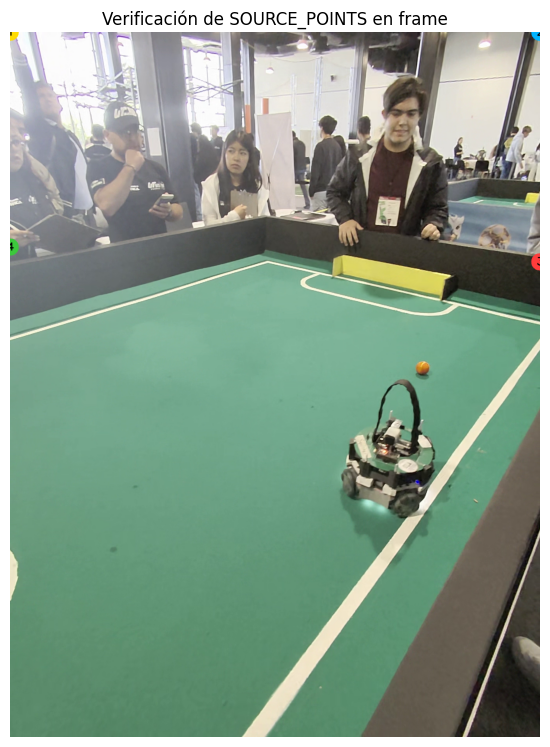

In [3]:
# Campo canónico objetivo
CAMPO_W, CAMPO_H = 364, 486
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico

TARGET_POINTS = np.float32([
    [       0,        0],   # 1 -> TL canónico
    [CAMPO_W,         0],   # 2 -> TR canónico
    [CAMPO_W, CAMPO_H  ],   # 3 -> BR canónico
    [       0, CAMPO_H ],   # 4 -> BL canónico
])

SOURCE_POINTS = np.array(SOURCE_POINTS, dtype=np.float32).reshape(4, 2)
TARGET_POINTS = np.array(TARGET_POINTS, dtype=np.float32).reshape(4, 2)

H = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)
print("Matriz H ")

PUNTO_COLORS = [(255, 220, 0), (0, 180, 255), (255, 60, 60), (60, 200, 60)]
vis = image_rgb.copy()
for idx, (pt, color) in enumerate(zip(SOURCE_POINTS, PUNTO_COLORS)):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis, (x, y), 22, color, -1)
    cv2.putText(vis, str(idx + 1), (x - 8, y + 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)

plt.figure(figsize=(5.6, 10))
plt.imshow(vis)
plt.title("Verificación de SOURCE_POINTS en frame")
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
from ultralytics import YOLO
import supervision as sv
import cv2
import numpy as np

model = YOLO("yucabot.pt")
tracker = sv.ByteTrack()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator()

COLORS_BGR  = {0: (216, 180, 0), 1: (60, 35, 239), 2: (0, 149, 255)}

def project_detections_yolo(detections: sv.Detections, H: np.ndarray) -> list:
    puntos = []
    if len(detections) == 0 or detections.tracker_id is None:
        return puntos
        
    for box, cid, tid in zip(detections.xyxy, detections.class_id, detections.tracker_id):
        # LÓGICA DE PERSPECTIVA 
        if int(cid) == 2:  # Si es el BALÓN -> Usamos el centroide
            cx = (box[0] + box[2]) / 2
            cy = (box[1] + box[3]) / 2  
        else:              # Si es ROBOT -> Usamos el centro de la base inferior
            cx = (box[0] + box[2]) / 2
            cy = box[3]                 
            
        pt = np.float32([[cx, cy]])
        proj = cv2.perspectiveTransform(pt.reshape(1, 1, 2), H)
        puntos.append({
            "pos": (int(proj[0][0][0]), int(proj[0][0][1])),
            "class_id": int(cid),
            "tracker_id": int(tid)
        })
    return puntos

def draw_tactical_canvas_tracked(puntos_canon: list, campo_w: int = CAMPO_W, campo_h: int = CAMPO_H) -> np.ndarray:
    canvas = np.zeros((campo_h, campo_w, 3), dtype=np.uint8)
    canvas[:] = (50, 67, 27)  # Verde oscuro pasto
    
    # Dibujar líneas base de la cancha
    cv2.rectangle(canvas, (0, 0), (campo_w - 1, campo_h - 1), (120, 200, 116), 2)
    cv2.line(canvas, (0, campo_h // 2), (campo_w, campo_h // 2), (120, 200, 116), 1)
    cv2.circle(canvas, (campo_w // 2, campo_h // 2), int(30 * ESCALA_PX_CM), (120, 200, 116), 1)
    
    # Porterías
    goal_w_px = int(60 * ESCALA_PX_CM)
    goal_x_px = (campo_w - goal_w_px) // 2
    cv2.rectangle(canvas, (goal_x_px, 0), (goal_x_px + goal_w_px, int(8 * ESCALA_PX_CM)), (0, 214, 255), 2)
    cv2.rectangle(canvas, (goal_x_px, campo_h - int(8 * ESCALA_PX_CM)), (goal_x_px + goal_w_px, campo_h - 1), (216, 180, 0), 2)
    
    for p in puntos_canon:
        x, y = p["pos"]
        cid  = p["class_id"]
        tid  = p["tracker_id"]
        
        # Ignorar puntos que caigan fuera del lienzo por falsos positivos
        if not (0 <= x < campo_w and 0 <= y < campo_h):
            continue
            
        color = COLORS_BGR.get(cid, (255, 255, 255))
        r = 7 if cid == 2 else 13
        cv2.circle(canvas, (x, y), r, color, -1)
        cv2.circle(canvas, (x, y), r, (255, 255, 255), 1)
        
        # Solo dibujamos el texto del Tracker_ID sobre los robots
        if cid != 2: 
            cv2.putText(canvas, str(tid), (x - 6, y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
            
    return canvas

In [5]:
video_path = "../VideosEjemplo/gael.mov"
OUTPUT_VIDEO = "assets/mapa_tactico_yucabot.mp4" 

tracker.reset()

original_info = sv.VideoInfo.from_video_path(video_path)

escala = CAMPO_H / original_info.height
orig_w = int(original_info.width * escala)

nuevo_ancho = orig_w + CAMPO_W + CAMPO_W
nuevo_alto = CAMPO_H

custom_video_info = sv.VideoInfo(width=nuevo_ancho, height=nuevo_alto, fps=original_info.fps)

def callback_yucabot(frame: np.ndarray, _: int) -> np.ndarray:
    # 1. Inferencia YOLO
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    
    # 2. Tracking (Actualizamos detecciones con ByteTrack)
    detections = tracker.update_with_detections(detections)
    
    # 3. Anotación Visual en el frame original
    # (Generamos las etiquetas con el nombre de clase + ID de tracking)
    labels = []
    for c, tid in zip(detections.class_id, detections.tracker_id):
        nombre_clase = results.names[c]
        labels.append(f"{nombre_clase} #{tid}")
        
    annotated_frame = frame.copy()
    annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
    
    # 4. Proyección Geométrica Diferenciada (Centroide vs Base) usando tu Matriz H
    puntos = project_detections_yolo(detections, H)
    
    # 5. Renderizado Táctico y Vista Cenital (Warp)
    tactical = draw_tactical_canvas_tracked(puntos)
    warped = cv2.warpPerspective(annotated_frame, H, (CAMPO_W, CAMPO_H))
    
    # 6. Redimensionar cámara para concatenar con los demás módulos
    resized = cv2.resize(annotated_frame, (orig_w, CAMPO_H))
    
    return np.hstack([resized, warped, tactical])

print(f"Exportando video final a resolución: {nuevo_ancho}x{nuevo_alto} px")
frames_generator = sv.get_video_frames_generator(video_path)

# Iterador principal con VideoSink
with sv.VideoSink(target_path=OUTPUT_VIDEO, video_info=custom_video_info) as sink:
    for i, frame in enumerate(frames_generator):
        resultado = callback_yucabot(frame, i)
        sink.write_frame(resultado)

print(f"{OUTPUT_VIDEO}")

Exportando video final a resolución: 1093x486 px


KeyboardInterrupt: 

## Prueba con el nuevo modelo

In [6]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

# ══════════════════════════════════════
# CARGAR MODELO POKOLPOK
# ══════════════════════════════════════
class FieldKeypointModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone      = models.efficientnet_b0(weights=None)
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 18)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

KP_NAMES = [
    "corner_tl", "corner_tr", "corner_br", "corner_bl",
    "post_a_left", "post_a_right", "post_b_left", "post_b_right",
    "center"
]

_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

device_kp   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pokolpok    = FieldKeypointModel().to(device_kp)
pokolpok.load_state_dict(torch.load("pokolpok.pth", map_location=device_kp))
pokolpok.eval()
print(f"✅ Modelo pokolpok cargado en {device_kp}")

# ══════════════════════════════════════
# FUNCIÓN DE INFERENCIA
# ══════════════════════════════════════
def detect_field_keypoints(frame_bgr):
    """
    Entrada : frame BGR (numpy array) de OpenCV
    Salida  : dict  { nombre_kp: (x, y) en píxeles }
              numpy (9, 2) con coordenadas reales
              (pueden ser negativas o fuera del frame si el punto no es visible)
    """
    H_frame, W_frame = frame_bgr.shape[:2]
    img  = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    inp  = _transform(img).unsqueeze(0).to(device_kp)

    with torch.no_grad():
        pred = pokolpok(inp).cpu().numpy()[0]

    coords = pred.reshape(9, 2)
    coords[:, 0] *= W_frame
    coords[:, 1] *= H_frame

    kp_dict = {KP_NAMES[i]: (float(coords[i, 0]), float(coords[i, 1]))
               for i in range(9)}
    return coords, kp_dict

# ══════════════════════════════════════
# PRUEBA CON FRAME DEL VIDEO
# ══════════════════════════════════════
cap = cv2.VideoCapture("../VideosEjemplo/gael.mov")
cap.set(cv2.CAP_PROP_POS_FRAMES, 380)
ret, frame = cap.read()
cap.release()

coords_np, kp_dict = detect_field_keypoints(frame)

# Extraer las 4 esquinas para calcular H (misma variable que usaba tu pipeline)
SOURCE_POINTS = np.array([
    kp_dict["corner_tl"],
    kp_dict["corner_tr"],
    kp_dict["corner_br"],
    kp_dict["corner_bl"]
], dtype=np.float32)

print("Keypoints detectados:")
for nombre, (x, y) in kp_dict.items():
    en_frame = 0 <= x <= frame.shape[1] and 0 <= y <= frame.shape[0]
    print(f"  {nombre:15s}: ({x:7.1f}, {y:7.1f}) {'✅' if en_frame else '⚠️ fuera'}")

print(f"\nSOURCE_POINTS (esquinas para homografía):\n{SOURCE_POINTS}")

✅ Modelo pokolpok cargado en cuda
Keypoints detectados:
  corner_tl      : (  870.9,   658.4) ✅
  corner_tr      : (-1373.0,  1733.6) ⚠️ fuera
  corner_br      : ( 1343.4,  1921.6) ⚠️ fuera
  corner_bl      : (  295.5,   959.4) ✅
  post_a_left    : (  185.7,   652.7) ✅
  post_a_right   : ( -729.1,  1279.3) ⚠️ fuera
  post_b_left    : (  536.6,   934.9) ✅
  post_b_right   : (  941.5,  1203.7) ✅
  center         : (  289.2,  1637.4) ✅

SOURCE_POINTS (esquinas para homografía):
[[     870.89      658.44]
 [      -1373      1733.6]
 [     1343.4      1921.6]
 [     295.51       959.4]]


## Exportamos el video

In [7]:
import cv2
import numpy as np

VIDEO_PATH   = "../VideosEjemplo/gael.mov"
OUTPUT_VIDEO = "assets/pokolpok_keypoints.mp4"

# Colores por tipo de keypoint (BGR)
COLORS = {
    "corner_tl"   : (0,  165, 255),  # naranja
    "corner_tr"   : (0,  165, 255),
    "corner_br"   : (0,  165, 255),
    "corner_bl"   : (0,  165, 255),
    "post_a_left" : (255, 255, 0),   # cyan
    "post_a_right": (255, 255, 0),
    "post_b_left" : (255, 255, 0),
    "post_b_right": (255, 255, 0),
    "center"      : (255, 120, 180), # lila
}

cap     = cv2.VideoCapture(VIDEO_PATH)
fps     = cap.get(cv2.CAP_PROP_FPS)
W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc  = cv2.VideoWriter_fourcc(*"mp4v")
out     = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (W, H))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Inferencia
    _, kp_dict = detect_field_keypoints(frame)

    # Dibujar cada keypoint
    for nombre, (x, y) in kp_dict.items():
        cx, cy    = int(round(x)), int(round(y))
        color     = COLORS[nombre]
        en_frame  = 0 <= cx < W and 0 <= cy < H

        if en_frame:
            # Punto visible — círculo sólido + etiqueta
            cv2.circle(frame, (cx, cy), 8, color, -1)
            cv2.circle(frame, (cx, cy), 8, (255,255,255), 1)
            cv2.putText(frame, nombre, (cx + 10, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
        else:
            # Punto fuera del frame — X en el borde más cercano
            bx = max(10, min(W - 10, cx))
            by = max(10, min(H - 10, cy))
            cv2.drawMarker(frame, (bx, by), color,
                           cv2.MARKER_CROSS, 18, 2)
            cv2.putText(frame, f"{nombre}*", (bx + 10, by),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    # Contador de frame
    cv2.putText(frame, f"Frame {frame_idx}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    out.write(frame)
    frame_idx += 1

    if frame_idx % 50 == 0:
        print(f"Procesando frame {frame_idx}...")

cap.release()
out.release()
print(f"\n✅ Video guardado en: {OUTPUT_VIDEO}")

Procesando frame 50...
Procesando frame 100...
Procesando frame 150...
Procesando frame 200...
Procesando frame 250...
Procesando frame 300...
Procesando frame 350...
Procesando frame 400...
Procesando frame 450...
Procesando frame 500...
Procesando frame 550...
Procesando frame 600...
Procesando frame 650...
Procesando frame 700...
Procesando frame 750...
Procesando frame 800...
Procesando frame 850...
Procesando frame 900...
Procesando frame 950...
Procesando frame 1000...
Procesando frame 1050...
Procesando frame 1100...

✅ Video guardado en: assets/pokolpok_keypoints.mp4


No funciona